# v2 — Làm sạch dữ liệu + đặc trưng phi tuyến

> Sửa nhầm chỗ: thay vì sửa cái thước đo, nhóm đi xóa những câu hỏi khó.

| | |
|---|---|
| Kênh tín hiệu | PPG (giống v1) |
| Cửa sổ | 30 giây, bước 30 giây (giống v1) |
| Đặc trưng | **16 cột** = 13 của v1 + SD1, SD2, SampEn |
| Làm sạch | luật theo nhãn, áp lên **toàn bộ** dữ liệu ❌ |
| Chia dữ liệu | ngẫu nhiên 80/20 ❌ (kế thừa v1) |
| Mô hình | LightGBM tinh chỉnh |
| **Điểm công bố** | **97.4%** |

## 1. Chuyện gì đã xảy ra

v1 sai 11 trên 269 cửa sổ. Nhóm mở từng ca sai ra xem, thấy chúng "trông kỳ
lạ", và kết luận: **đây là nhãn nhiễu** — dữ liệu bị gắn nhãn sai chứ mô hình
không sai. Thế là viết luật xóa chúng đi.

Đây là một phản xạ rất tự nhiên và rất nguy hiểm. Ta sẽ xem vì sao.

In [1]:
import os, sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CWD = os.path.abspath('')
SRC = os.path.dirname(CWD) if os.path.basename(CWD) == 'report' else CWD
if SRC not in sys.path:
    sys.path.insert(0, SRC)

from vlab import store, viz, honest
from vlab.extract import extract_table

pd.set_option('display.width', 120)
pd.set_option('display.max_columns', 40)
%matplotlib inline
print('San sang. src =', SRC)


San sang. src = D:\Projects\HealthSense\HealthSense-MachineLearning-Lab\src


In [2]:
import v2
r = store.load('v2')
if r is None:
    r = v2.run()

print('Cấu hình v2:')
for k, val in r['config'].items():
    if k != 'features':
        print(f'  {k:12}: {val}')
print()
print('Ba đặc trưng MỚI so với v1: SD1, SD2, SampEn (nhóm phi tuyến)')

Cấu hình v2:
  channel     : PPG
  window_s    : 30.0
  step_s      : 30.0
  overlap_pct : 0.0
  n_features  : 16
  cleaning    : luật theo nhãn (SDNN/RMSSD/pNN50), áp lên toàn bộ dữ liệu
  scaling     : StandardScaler trong Pipeline
  split       : ngẫu nhiên theo cửa sổ 80/20
  model       : LightGBM (n=200, lr=0.1)

Ba đặc trưng MỚI so với v1: SD1, SD2, SampEn (nhóm phi tuyến)


## 2. Đóng góp thật của v2: ba đặc trưng phi tuyến

Trước khi nói về chỗ sai, phải ghi nhận phần đúng. v2 thêm ba chỉ số:

- **SD1, SD2** — độ rộng và độ dài của "đám mây Poincaré" (mỗi điểm là một
  cặp nhịp liên tiếp). Nhịp đều → chấm chụm; nhịp loạn → chấm tản.
- **SampEn** (Sample Entropy) — đo độ "khó đoán" của chuỗi nhịp. Nhìn 2 nhịp
  vừa rồi có đoán được nhịp tiếp theo không? Với AFib thì gần như không.

Ba cột này là đóng góp thật và được giữ nguyên đến v4. Hãy xem chúng tách
bạch hai nhóm tốt đến đâu:

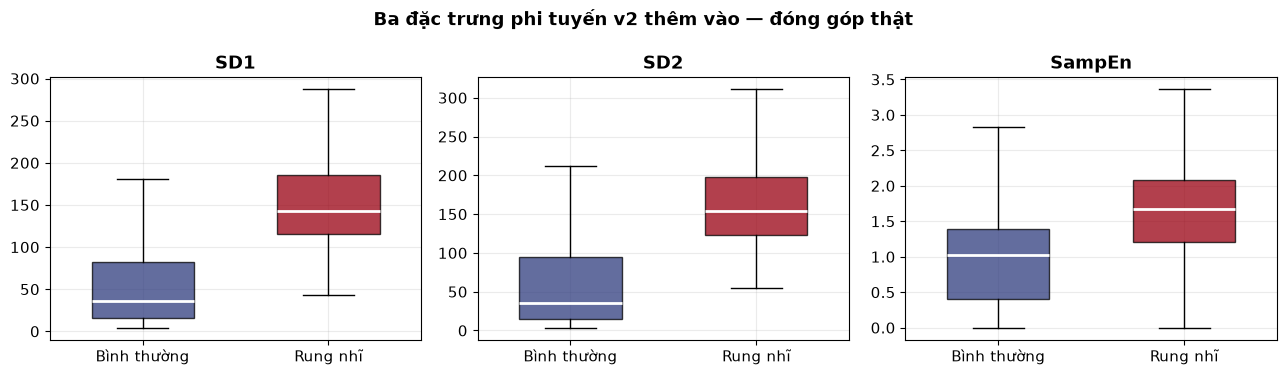

In [3]:
df = extract_table('PPG', 30.0, 30.0, verbose=False)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, feat in zip(axes, ['SD1', 'SD2', 'SampEn']):
    data = [df[df.status == 0][feat], df[df.status == 1][feat]]
    bp = ax.boxplot(data, tick_labels=['Bình thường', 'Rung nhĩ'],
                    showfliers=False, patch_artist=True, widths=0.55)
    for patch, c in zip(bp['boxes'], [viz.NAVY, viz.CHERRY]):
        patch.set_facecolor(c); patch.set_alpha(0.75)
    for m in bp['medians']:
        m.set_color('white'); m.set_linewidth(2)
    ax.set_title(feat)
fig.suptitle('Ba đặc trưng phi tuyến v2 thêm vào — đóng góp thật',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 3. Chỗ sai: luật làm sạch dựa trên NHÃN

Luật của v2, viết lại cho dễ đọc:

```
Xóa nếu: nhãn = Bình thường  VÀ  (SDNN > 300 hoặc RMSSD > 400 hoặc pNN50 > 90)
Xóa nếu: nhãn = AFib         VÀ  SDNN < 50  VÀ  pNN50 < 20
```

Hãy đọc kỹ luật này nói gì. Nó xóa:
- những người **bình thường mà nhịp trông hỗn loạn**, và
- những ca **AFib mà nhịp lại trông đều đặn**.

Tức là chính xác **những ca khó nhất**. Và luật được áp lên **toàn bộ dữ liệu,
kể cả tập test** — nên những ca khó bị xóa khỏi đề thi luôn.

Xem thực tế nó xóa gì:

In [4]:
from v2.pipeline import label_conditioned_mask

keep = label_conditioned_mask(df)
bi_xoa = df[~keep]

print(f"Tổng cửa sổ            : {len(df)}")
print(f"Bị luật xóa            : {len(bi_xoa)}  ({len(bi_xoa)/len(df)*100:.1f}%)")
print(f"  trong đó AFib        : {int((bi_xoa['status']==1).sum())}")
print(f"  trong đó Bình thường : {int((bi_xoa['status']==0).sum())}")
print()
print('Số bệnh nhân bị ảnh hưởng:', bi_xoa['record_id'].nunique())
print()
print('Các cửa sổ bị xóa thuộc về:')
print(bi_xoa['record_id'].value_counts().head(8).to_string())

Tổng cửa sổ            : 1400
Bị luật xóa            : 51  (3.6%)
  trong đó AFib        : 1
  trong đó Bình thường : 50

Số bệnh nhân bị ảnh hưởng: 5

Các cửa sổ bị xóa thuộc về:
record_id
mimic_perform_non_af_012    40
mimic_perform_non_af_014     8
mimic_perform_af_017         1
mimic_perform_non_af_001     1
mimic_perform_non_af_007     1


Gần như toàn bộ cửa sổ bị xóa là **ca Normal khó** — người bình thường
có nhịp bất thường.

Đây chính xác là loại ca mà sản phẩm ngoài đời sẽ gặp thường xuyên: người
khỏe mạnh đang tập thể dục, đang lo lắng, hoặc đeo vòng hơi lỏng. Xóa họ khỏi
đề thi làm điểm đẹp lên, nhưng sản phẩm thật vẫn phải đối mặt với họ.

Hãy nhìn xem những cửa sổ bị xóa "khó" đến mức nào so với phần còn lại:

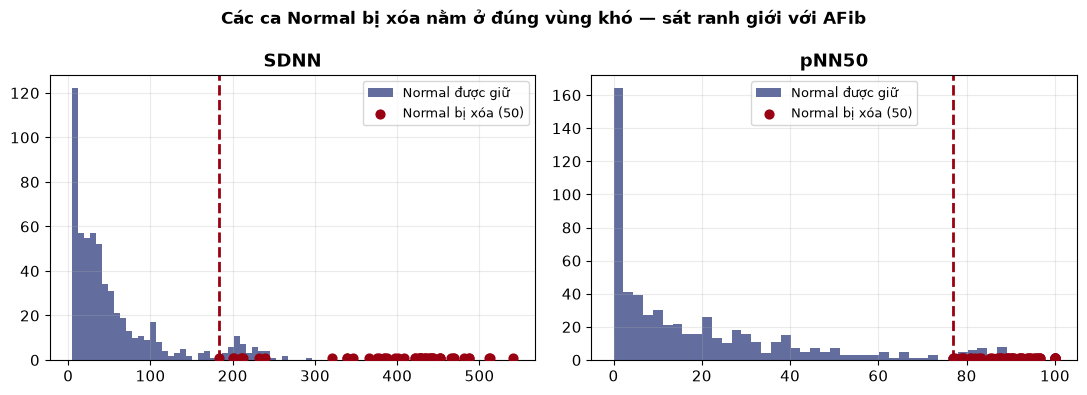

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, feat in zip(axes, ['SDNN', 'pNN50']):
    normal_giu = df[keep & (df.status == 0)][feat]
    normal_xoa = bi_xoa[bi_xoa.status == 0][feat]
    ax.hist(normal_giu, bins=40, color=viz.NAVY, alpha=0.75, label='Normal được giữ')
    if len(normal_xoa):
        ax.axvline(normal_xoa.min(), color=viz.CHERRY, linestyle='--', linewidth=2)
        ax.scatter(normal_xoa, np.full(len(normal_xoa), 1), color=viz.CHERRY,
                   s=40, zorder=5, label=f'Normal bị xóa ({len(normal_xoa)})')
    ax.set_title(feat); ax.legend(fontsize=9)
fig.suptitle('Các ca Normal bị xóa nằm ở đúng vùng khó — sát ranh giới với AFib',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## 4. Lỗi thứ ba: chọn ngưỡng bằng điểm test

Còn một lỗi tinh vi hơn trong notebook gốc `08_data_driven_sqi_tuning`:
nhóm thử nhiều ngưỡng lọc tín hiệu (SQI), huấn luyện lại với từng ngưỡng, rồi
**đọc điểm trên tập test** để chọn ngưỡng tốt nhất.

Sai ở hai tầng:
1. Ngưỡng là một **hyperparameter**. Chọn nó bằng điểm test là nhìn trộm đáp án.
2. Mỗi ngưỡng lại **thay đổi luôn thành phần tập test** — nên các con số thậm
   chí không so sánh được với nhau.

Tái dựng "đường cong cám dỗ" đó:

,Ngưỡng,Giữ lại (%),Accuracy test,Recall
0,1.0,100.0,0.9786,0.9934
1,2.0,100.0,0.9786,0.9934
2,3.0,100.0,0.9786,0.9934
3,5.0,100.0,0.9786,0.9934
4,10.0,100.0,0.9786,0.9934


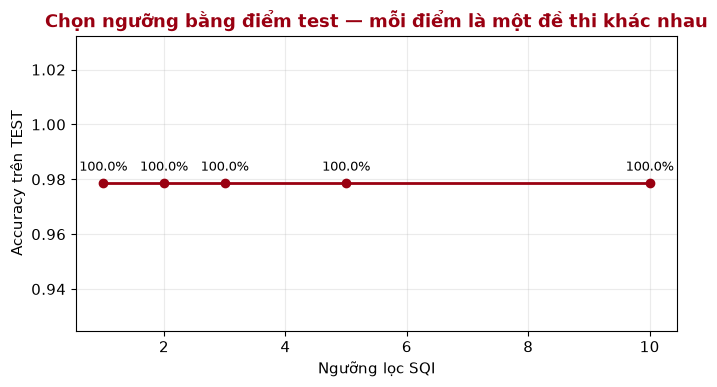

In [6]:
sweep = v2.sqi_threshold_sweep(df)
display(sweep)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sweep['Ngưỡng'], sweep['Accuracy test'], 'o-', color=viz.CHERRY, linewidth=2)
for _, row in sweep.iterrows():
    ax.annotate(f"{row['Giữ lại (%)']}%", (row['Ngưỡng'], row['Accuracy test']),
                textcoords='offset points', xytext=(0, 9), ha='center', fontsize=9)
ax.set_xlabel('Ngưỡng lọc SQI'); ax.set_ylabel('Accuracy trên TEST')
ax.set_title('Chọn ngưỡng bằng điểm test — mỗi điểm là một đề thi khác nhau',
             color=viz.CHERRY)
plt.tight_layout(); plt.show()

Nhìn biểu đồ này rất dễ bị cám dỗ chọn điểm cao nhất. Nhưng nhãn "%"
bên trên mỗi điểm cho thấy mỗi ngưỡng giữ lại một lượng dữ liệu khác nhau —
tức là **các cột điểm này không cùng một đề thi**, không so sánh được.

Cách làm đúng: chọn ngưỡng bằng tập validation tách riêng (hoặc nested CV),
rồi chỉ chạm vào test **một lần duy nhất** ở cuối cùng.

## 5. Chấm lại bằng LOSO

Bản trung thực của cùng ý tưởng: luật làm sạch **chỉ được nhìn dữ liệu train**
của từng fold; tập test giữ nguyên 100%.

,Cách chấm,Accuracy,Recall,Specificity,ROC-AUC
0,Gốc: lọc toàn cục + chia ngẫu nhiên,0.9889,1.0000,0.9746,0.9979
1,Trung thực: lọc chỉ trên train + LOSO,0.9257,0.9829,0.8578,0.9329


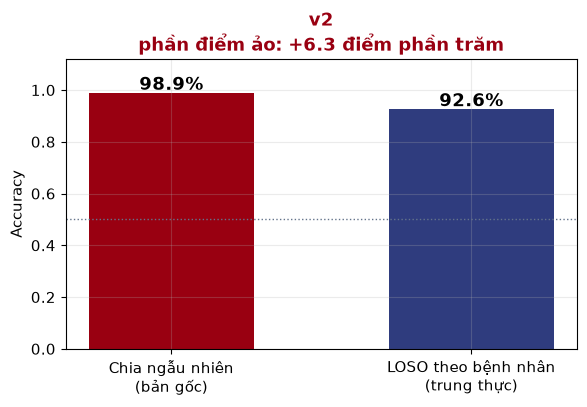

In [7]:
leaky, loso_w, loso_s = r['reproduced_leaky'], r['regraded_loso_window'], r['regraded_loso_subject']

so_sanh = pd.DataFrame([
    {'Cách chấm': 'Gốc: lọc toàn cục + chia ngẫu nhiên',
     'Accuracy': leaky['accuracy'], 'Recall': leaky['recall'],
     'Specificity': leaky['specificity'], 'ROC-AUC': leaky['roc_auc']},
    {'Cách chấm': 'Trung thực: lọc chỉ trên train + LOSO',
     'Accuracy': loso_w['accuracy'], 'Recall': loso_w['recall'],
     'Specificity': loso_w['specificity'], 'ROC-AUC': loso_w['roc_auc']},
])
display(so_sanh)

fig = viz.leakage_gap(leaky['accuracy'], loso_w['accuracy'], title='v2')
plt.show()

In [8]:
v1r = store.load('v1')
if v1r:
    print('So với v1 — cùng chấm bằng LOSO:')
    print(f"  v1: {v1r['regraded_loso_window']['accuracy']*100:.2f}%")
    print(f"  v2: {loso_w['accuracy']*100:.2f}%")
    delta = (loso_w['accuracy'] - v1r['regraded_loso_window']['accuracy']) * 100
    print(f"  chênh lệch thật: {delta:+.2f} điểm phần trăm")
    print()
    print('Trong khi đó điểm CÔNG BỐ tăng từ 95.9% lên 97.4% (+1.5 điểm).')
    print('Phần lớn "tiến bộ" đó không có thật.')

So với v1 — cùng chấm bằng LOSO:
  v1: 92.07%
  v2: 92.57%
  chênh lệch thật: +0.50 điểm phần trăm

Trong khi đó điểm CÔNG BỐ tăng từ 95.9% lên 97.4% (+1.5 điểm).
Phần lớn "tiến bộ" đó không có thật.


## 6. Bài học rút ra

1. **"Nhãn nhiễu" là một chẩn đoán, không phải một sự thật.** Trước khi xóa
   dữ liệu vì cho rằng nhãn sai, phải có bằng chứng độc lập — ví dụ đối chiếu
   với ECG đo song song. Dự án này về sau đã làm đúng điều đó và phát hiện
   ca `non_af_012` thật sự bị gắn nhãn sai.

2. **Không bao giờ để luật làm sạch nhìn thấy nhãn của tập test.** Muốn lọc
   thì lọc dựa trên **chất lượng tín hiệu** (đo được mà không cần nhãn), và
   chỉ áp lên train.

3. **Mỗi lần bạn nhìn vào điểm test để ra quyết định, bạn đã tiêu một phần
   giá trị của nó.** Test chỉ nên được chạm vào một lần, ở cuối cùng.

4. **Thêm đặc trưng tốt vẫn là tiến bộ thật** — SD1/SD2/SampEn sống đến v4.
   Vấn đề là nó bị trộn lẫn với phần tăng điểm giả, khiến không ai biết đóng
   góp thật là bao nhiêu.

➡️ Tiếp theo: [`03_v3_report.ipynb`](03_v3_report.ipynb) — bốn lỗi chồng lên nhau,
và con số 98.7% đẹp nhất lịch sử dự án.